# Figures for in vivo TadA-LN and TadA-GFPNb Libraries

Figure 5 and S4

### Load Libraries and Analysis-Wide Variables

In [ ]:
options(warn = -1)

suppressPackageStartupMessages({
  library(plyranges)
  library(tidyverse)
  library(rasilabRtemplates)
  library(ggpubr)
  library(RColorBrewer)
  library(cowplot)
})

wildtype_boxb <- "GGGCCCTGAAGAAGGGCCC"
wildtype_boxb_rc <- "GGGCCCTTCTTCAGGGCCC"
time_order=c("37_30min","37_1hr","37_2hr")
position_order=c("5","3")
enzyme_order<-c("none","tada_ln","tada_gfpnb")

In [2]:
target_data <- list.files("../data/summary_stats_combined/", full.names = T, pattern = ".csv.gz") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    print()

in_vitro_data <- list.files("../../2024-09-05_i83_tada_lambdaN_pAG_boxb_oligo_pool/data/summary_stats_combined/", full.names = T, pattern = ".csv.gz") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    print()

# A tibble: 11,882 × 89
   sample_id barcode    insert umi_cou…¹ num_0_a num_0_g num_0_t num_0_c num_0_n
   <chr>     <chr>      <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 i79_p21   AAAAGACAGG GTGT         484     484     483       0     465     484
 2 i79_p21   AAAAGACAGG TAAA         237     237     237       0     231     237
 3 i79_p21   AAAAGACAGG AAAC          74      74      74       0      64      74
 4 i79_p21   AAAAGACAGG TGTG         869     869     869       0     831     869
 5 i79_p21   AAAAGACAGG CTCG          84      84      84       0      76      84
 6 i79_p21   AAAAGACAGG GTAA         245     244     245       0     238     245
 7 i79_p21   AAAAGACAGG GTGA         358     358     358       0     356     358
 8 i79_p21   AAAAGACAGG GGGC         238     238     238       0     230     238
 9 i79_p21   AAAAGACAGG TTGG         455     455     455       0     421     455
10 i79_p21   AAAAGACAGG AGGG         589     589     589       0     558     589
# … 

In [3]:
barcode_annotations <- read_csv("../annotations/barcode_annotations.csv", show_col_types = F) %>%
    select(-barcode) %>%
    rename(barcode = reverse_complement) %>%
    print()

sample_annotations <- read_csv("../annotations/sample_info.csv", show_col_types = F) %>%
    print()

hairpin_annotations <- read_tsv("../annotations/hairpin_annotations.tsv", show_col_types = F) %>%
    rename("insert" = "variable_region") %>%
    print()

target_data <- target_data %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(sample_annotations, by = "sample_id") %>%
    print()
     

# A tibble: 32 × 15
   barcode    oligo_name oligo…¹ n_var…² varia…³ varia…⁴ targe…⁵ targe…⁶ targe…⁷
   <chr>      <chr>      <chr>     <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 AAGACGCCCA spacer5_1… CAAACG…      64      28       3      42      17       5
 2 CGCGGGACCG spacer3_1… CAAACG…      64      76       3      22      17       3
 3 CGAAAAGAGC spacer5_0… CAAACG…      64      28       3      32      17       5
 4 CCGCACCGCC spacer3_0… CAAACG…      64      76       3      12      17       3
 5 CGAAACAGAA spacer5_1… CAAACG…      64      25       3      42      17       5
 6 GGCGCACAGA spacer3_1… CAAACG…      64      73       3      22      17       3
 7 CAACCAGCCA spacer5_0… CAAACG…      64      25       3      32      17       5
 8 AGAAAGACCA spacer3_0… CAAACG…      64      73       3      12      17       3
 9 AAAAGACAGG spacer5_1… CAAACG…     256      21       4      42      17       5
10 CCACCGAGCC spacer3_1… CAAACG…     256      69       4      22      17       3
# … with

In [4]:
in_vitro_barcode_annotations <- read_csv("../../2024-09-05_i83_tada_lambdaN_pAG_boxb_oligo_pool/annotations/barcode_annotations.csv", show_col_types = F) %>%
    select(-barcode) %>%
    rename(barcode = reverse_complement) %>%
    print()

in_vitro_sample_annotations <- read_csv("../../2024-09-05_i83_tada_lambdaN_pAG_boxb_oligo_pool/annotations/sample_info.csv", show_col_types = F) %>%
    print()

hairpin_annotations <- read_tsv("../annotations/hairpin_annotations.tsv", show_col_types = F) %>%
    rename("insert" = "variable_region") %>%
    print()

in_vitro_target_data <- in_vitro_data %>%
    left_join(in_vitro_barcode_annotations, by = "barcode") %>%
    left_join(in_vitro_sample_annotations, by = "sample_id") %>%
    print()


in_vitro_tmp <-in_vitro_target_data %>%
    filter(variable_type=="boxb") %>%
    filter(umi_counts>100)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(sample_id,variable_subpos,insert,fraction_edited,tada_type) %>%
    group_by(sample_id,variable_subpos,insert,tada_type)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
        across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
        .groups = "drop")%>%
    select(sample_id,variable_subpos,insert,mean_fraction_edited)%>%
    pivot_wider(names_from=sample_id,values_from = mean_fraction_edited)%>%
    print()


# A tibble: 96 × 14
   barcode    oligo_name n_var…¹ varia…² varia…³ targe…⁴ targe…⁵ targe…⁶ targe…⁷
   <chr>      <chr>        <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 AAGACGCCCA spacer5_3…    1024      62      17      62      17       5      30
 2 CGCGGGACCG spacer3_3…    1024      42      17      42      17       3       0
 3 CGAAAAGAGC spacer5_3…    1024      62      17      62      17       5      30
 4 CCGCACCGCC spacer3_3…    1024      42      17      42      17       3       0
 5 CGAAACAGAA spacer5_2…    1024      60      17      60      17       5      28
 6 GGCGCACAGA spacer3_2…    1024      40      17      40      17       3       2
 7 CAACCAGCCA spacer5_2…    1024      60      17      60      17       5      28
 8 AGAAAGACCA spacer3_2…    1024      40      17      40      17       3       2
 9 AAAAGACAGG spacer5_2…    1024      58      17      58      17       5      26
10 CCACCGAGCC spacer3_2…    1024      38      17      38      17       3       4
# … with

In [5]:
wildtype_boxb_random_inserts <- barcode_annotations  %>%
  filter(str_detect(oligo_name, "boxb_random")) %>%
  distinct(variable_subpos)  %>%
  separate(variable_subpos, c("start", "end"), remove = F) %>%
  mutate(wt_insert = c("CCC","GGG","TTCA","TTCT","CCC","GGG")) %>%
  # mutate(wt_insert = str_sub(wt_seq, as.numeric(start), as.numeric(end)))  %>%
  select(variable_subpos, wt_insert)


wildtype_boxb_random_inserts

variable_subpos,wt_insert
<chr>,<chr>
1_3,CCC
4_6,GGG
7_10,TTCA
10_13,TTCT
14_16,CCC
17_19,GGG


## Generate Data Tables

### In Vivo Mean Editing: Wild-type BoxB

In [6]:
options(repr.plot.width = 5, repr.plot.height = 4)
enzyme_order<-c("none","tada_ln","tada_gfpnb")

mean_editing_in_vivo <- target_data  %>%
  filter(variable_type=="boxb",g_depleted=="no") %>%
  inner_join(wildtype_boxb_random_inserts, by = c("variable_subpos", "insert" = "wt_insert")) %>%
  mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c) %>%
  select(sample_id, sample_name, variable_subpos, matches("fraction_"),enzyme) %>%
  group_by(enzyme) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  .groups = "drop")%>%
  print()

  write_tsv(mean_editing_in_vivo,"../tables/mean_editing_in_vivo.tsv")

# A tibble: 3 × 3
  enzyme        mean       se
  <chr>        <dbl>    <dbl>
1 none       0.00358 0.000831
2 tada_gfpnb 0.152   0.0106  
3 tada_ln    0.153   0.0128  


### Editing at Individual Adenines in Recorder

In [ ]:
individual_a_editing_context_constant <- target_data  %>%
  filter(g_depleted=="no") %>%
  inner_join(wildtype_boxb_random_inserts, by = c("variable_subpos", "insert" = "wt_insert")) %>%
  mutate(across(matches("pos_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}")) %>%
  select(enzyme, matches("fraction_")) %>%
  group_by(enzyme)%>%
  summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    n=n(),
    .groups = "drop")%>%
      pivot_longer(
      cols = c(starts_with("mean_"),starts_with("se_")), 
      names_to = c(".value", "position"),
      names_pattern = "(mean|se)_fraction_pos_(\\d+)_c"
    )%>%
  group_by(enzyme)%>%
  mutate(scaled_mean = rank(mean))%>%
  print()

  write_tsv(individual_a_editing_context_constant,"../tables/individual_a_editing_context_constant.tsv")
  

# A tibble: 24 × 6
# Groups:   enzyme [3]
   enzyme         n position     mean        se scaled_mean
   <chr>      <int> <chr>       <dbl>     <dbl>       <dbl>
 1 none          24 0        0.00155  0.000683            8
 2 none          24 1        0.000354 0.0000836           3
 3 none          24 2        0.000452 0.000134            6
 4 none          24 3        0.000357 0.0000639           4
 5 none          24 4        0.000248 0.0000477           1
 6 none          24 5        0.000505 0.0000863           7
 7 none          24 6        0.000308 0.0000610           2
 8 none          24 7        0.000406 0.0000902           5
 9 tada_gfpnb    24 0        0.0156   0.00264             3
10 tada_gfpnb    24 1        0.0340   0.00404             6
# … with 14 more rows


### Mean Editing per BoxB Variant: Wide Table for Correlations Between Conditions

In [56]:
mean_editing_per_boxb_variants_wide <- target_data %>%
    filter(variable_type=="boxb") %>%
    filter(umi_counts>200)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(sample_id,variable_subpos,insert,fraction_edited,enzyme) %>%
    group_by(sample_id,variable_subpos,insert,enzyme)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
        across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
        .groups = "drop")%>%
    select(sample_id,variable_subpos,insert,mean_fraction_edited)%>%
    pivot_wider(names_from=sample_id,values_from = mean_fraction_edited)%>%
    right_join(in_vitro_tmp,by=c("variable_subpos","insert"))%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
    print()

write_tsv(mean_editing_per_boxb_variants_wide,"../tables/mean_editing_per_boxb_variants_wide.tsv")

# A tibble: 661 × 27
   variable_sub…¹ insert i79_p21 i79_p22 i79_p23  i79_p1 i79_p10 i79_p11 i79_p12
   <chr>          <chr>    <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 1_3            AAA     0.111    0.165 7.84e-4 0.00289   0.344  0.107   0.0350
 2 1_3            AAC     0.157    0.167 3.03e-3 0.00302   0.414  0.113   0.0312
 3 1_3            AAG     0.100    0.138 1.46e-3 0.00300   0.190  0.0423  0.0120
 4 1_3            AAT     0.0992   0.130 1.66e-3 0.00209   0.261  0.0827  0.0296
 5 1_3            ACA     0.175    0.185 1.79e-3 0.00327   0.427  0.149   0.0436
 6 1_3            ACC     0.161    0.157 2.02e-3 0.00615   0.508  0.186   0.0676
 7 1_3            ACG     0.147    0.163 1.42e-3 0.00308   0.388  0.120   0.0351
 8 1_3            ACT     0.127    0.141 1.43e-3 0.00350   0.259  0.0908  0.0244
 9 1_3            AGA     0.122    0.154 2.48e-3 0.00258   0.309  0.0862  0.0198
10 1_3            AGC     0.133    0.124 1.68e-3 0.00567   0.399  0.124   0.0350
# … wit

### Editing per Loop Variant for GNRNA Violin Comparisons

In [17]:
stats_per_boxb_insert <- target_data %>%
    filter(variable_type=="boxb") %>%
    filter(umi_counts>200)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(enzyme,variable_subpos,insert, fraction_edited) %>%
    group_by(variable_subpos,insert)%>%
    # summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    # across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    # .groups = "drop")%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
print()

loop_data_tmp <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("7_10"))%>%
    mutate(boxb_7=str_sub(insert,4,4),
        boxb_8=str_sub(insert,3,3),
        boxb_9=str_sub(insert,2,2),
        boxb_10=str_sub(insert,1,1),
        boxb_11="C",
        boxb_12="T",
        boxb_13="T")%>%
    print()

editing_per_loop_variant <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("10_13"))%>%
    mutate(boxb_7="A",
        boxb_8="C",
        boxb_9="T",
        boxb_10=str_sub(insert,4,4),
        boxb_11=str_sub(insert,3,3),
        boxb_12=str_sub(insert,2,2),
        boxb_13=str_sub(insert,1,1))%>%
    bind_rows(loop_data_tmp)%>%
    mutate(gnra=boxb_8=="C"&(boxb_10=="T"|boxb_10=="C")&boxb_12=="T",
        boxb_8_rc=case_when(
        boxb_8=="A" ~ "T",
        boxb_8=="C" ~ "G",
        boxb_8=="G" ~ "C",
        boxb_8=="T" ~ "A"
        ), boxb_10_rc=case_when(
        boxb_10=="A" ~ "T",
        boxb_10=="C" ~ "G",
        boxb_10=="G" ~ "C",
        boxb_10=="T" ~ "A"
        ), boxb_12_rc=case_when(
        boxb_12=="A" ~ "T",
        boxb_12=="C" ~ "G",
        boxb_12=="G" ~ "C",
        boxb_12=="T" ~ "A"
        ))%>%
    print()

write_tsv(editing_per_loop_variant,"../tables/editing_per_loop_variant.tsv")

# A tibble: 6,835 × 6
# Groups:   variable_subpos, insert [613]
   enzyme  variable_subpos insert fraction_edited free_energy hairpin           
   <chr>   <chr>           <chr>            <dbl>       <dbl> <chr>             
 1 tada_ln 7_10            GTGT           0.0393        -12.1 GGGCCCACACGAAGGGC…
 2 tada_ln 7_10            TAAA           0.0253        -13.7 GGGCCCTTTAGAAGGGC…
 3 tada_ln 7_10            TGTG           0.0437        -11.6 GGGCCCCACAGAAGGGC…
 4 tada_ln 7_10            GTAA           0.0286        -13.7 GGGCCCTTACGAAGGGC…
 5 tada_ln 7_10            GTGA           0.00559       -13.2 GGGCCCTCACGAAGGGC…
 6 tada_ln 7_10            GGGC           0.0336        -12.9 GGGCCCGCCCGAAGGGC…
 7 tada_ln 7_10            TTGG           0.0747        -11.6 GGGCCCCCAAGAAGGGC…
 8 tada_ln 7_10            AGGG           0.0526        -11.6 GGGCCCCCCTGAAGGGC…
 9 tada_ln 7_10            TTTT           0.0348        -12.1 GGGCCCAAAAGAAGGGC…
10 tada_ln 7_10            TAAG           0.0

### Mean Editing per BoxB Stem Variant

In [60]:
options(repr.plot.width = 8, repr.plot.height = 5) 

mean_editing_stem_variants <- target_data %>%
    filter(variable_type=="boxb") %>%
    filter(variable_subpos %in% c("1_3","4_6","14_16","17_19"))%>%
    # filter(umi_counts>100)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(enzyme,variable_subpos,insert, fraction_edited) %>%
    group_by(enzyme,variable_subpos,insert)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    .groups = "drop")%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
    group_by(enzyme)%>%
    arrange(free_energy)%>%
    mutate(energy_bins=ntile(row_number(),5),)%>%
print()
   
write_tsv(mean_editing_stem_variants,"../tables/mean_editing_stem_variants.tsv")


# A tibble: 772 × 8
# Groups:   enzyme [3]
   enzyme     variable_subpos insert mean_frac…¹ se_fr…² free_…³ hairpin energ…⁴
   <chr>      <chr>           <chr>        <dbl>   <dbl>   <dbl> <chr>     <int>
 1 none       1_3             CCC        0.00217 3.57e-4   -14.5 GGGCCC…       1
 2 none       14_16           CCC        0.00262 7.75e-4   -14.5 GGGCCC…       1
 3 none       17_19           GGG        0.00409 1.96e-3   -14.5 GGGCCC…       1
 4 none       4_6             GGG        0.00384 1.26e-3   -14.5 GGGCCC…       1
 5 tada_gfpnb 1_3             CCC        0.195   2.89e-2   -14.5 GGGCCC…       1
 6 tada_gfpnb 14_16           CCC        0.167   2.53e-2   -14.5 GGGCCC…       1
 7 tada_gfpnb 17_19           GGG        0.174   3.54e-2   -14.5 GGGCCC…       1
 8 tada_gfpnb 4_6             GGG        0.143   7.68e-3   -14.5 GGGCCC…       1
 9 tada_ln    1_3             CCC        0.196   3.28e-2   -14.5 GGGCCC…       1
10 tada_ln    14_16           CCC        0.163   3.85e-2   -14.5 G

### Mean Editing per BoxB Loop Variant (for heatmaps)

In [11]:
enzyme_order=c("none","tada_ln","tada_gfpnb")
facet_labels <- c("No Enzyme","TadA-LN","TadA-GFPNb")
names(facet_labels)<-enzyme_order


stats_per_boxb_insert <- target_data %>%
    filter(variable_type=="boxb", g_depleted=="no") %>%
    # filter(umi_counts>100)%>%
    mutate(across(matches("num_._c"), ~ round(.x / umi_counts, 5), .names = "fraction_{col}"),
        fraction_edited=1-fraction_num_0_c)%>%
    select(variable_subpos,insert, enzyme, fraction_edited) %>%
    group_by(variable_subpos,insert,enzyme)%>%
    summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    .groups = "drop")%>%
    left_join(hairpin_annotations,by=c("variable_subpos","insert"))%>%
print()

loop_data_tmp <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("7_10"))%>%
    mutate(boxb_7=str_sub(insert,4,4),
        boxb_8=str_sub(insert,3,3),
        boxb_9=str_sub(insert,2,2),
        boxb_10=str_sub(insert,1,1),
        boxb_11="C",
        boxb_12="T",
        boxb_13="T")%>%
    print()

mean_editing_per_loop_variant <- stats_per_boxb_insert %>%
    filter(variable_subpos %in% c("10_13"))%>%
    mutate(boxb_7="A",
        boxb_8="C",
        boxb_9="T",
        boxb_10=str_sub(insert,4,4),
        boxb_11=str_sub(insert,3,3),
        boxb_12=str_sub(insert,2,2),
        boxb_13=str_sub(insert,1,1))%>%
    bind_rows(loop_data_tmp)%>%
    mutate(gnra=boxb_8=="C"&(boxb_10=="T"|boxb_10=="C")&boxb_12=="T",
        boxb_8_rc=case_when(
        boxb_8=="A" ~ "U",
        boxb_8=="C" ~ "G",
        boxb_8=="G" ~ "C",
        boxb_8=="T" ~ "A"
        ), boxb_10_rc=case_when(
        boxb_10=="A" ~ "U",
        boxb_10=="C" ~ "G",
        boxb_10=="G" ~ "C",
        boxb_10=="T" ~ "A"
        ), boxb_12_rc=case_when(
        boxb_12=="A" ~ "U",
        boxb_12=="C" ~ "G",
        boxb_12=="G" ~ "C",
        boxb_12=="T" ~ "A"
        ),boxb_7_rc=case_when(
        boxb_7=="A" ~ "U",
        boxb_7=="C" ~ "G",
        boxb_7=="G" ~ "C",
        boxb_7=="T" ~ "A"
        ), boxb_13_rc=case_when(
        boxb_13=="A" ~ "U",
        boxb_13=="C" ~ "G",
        boxb_13=="G" ~ "C",
        boxb_13=="T" ~ "A"
        ))%>%
    print()

write_tsv(mean_editing_per_loop_variant,"../tables/mean_editing_per_loop_variant")

# A tibble: 2,299 × 7
   variable_subpos insert enzyme     mean_fraction_edi…¹ se_fr…² free_…³ hairpin
   <chr>           <chr>  <chr>                    <dbl>   <dbl>   <dbl> <chr>  
 1 1_3             AAA    none                  0.000688 5.23e-4      -5 TTTCCC…
 2 1_3             AAA    tada_gfpnb            0.157    3.53e-2      -5 TTTCCC…
 3 1_3             AAA    tada_ln               0.0735   1.15e-2      -5 TTTCCC…
 4 1_3             AAC    none                  0.00390  1.20e-3      -5 GTTCCC…
 5 1_3             AAC    tada_gfpnb            0.156    5.59e-2      -5 GTTCCC…
 6 1_3             AAC    tada_ln               0.0585   2.37e-2      -5 GTTCCC…
 7 1_3             AAG    none                  0.00159  8.35e-4      -5 CTTCCC…
 8 1_3             AAG    tada_gfpnb            0.108    6.83e-3      -5 CTTCCC…
 9 1_3             AAG    tada_ln               0.0691   7.43e-3      -5 CTTCCC…
10 1_3             AAT    none                  0.00223  9.23e-4      -5 ATTCCC…
# … wi

## Figure 5

### 5B

In [ ]:
figure_5b <- mean_editing_in_vivo  %>%
  ggplot(aes(x = factor(enzyme,levels=enzyme_order), y = mean*100)) +  
  geom_point(size=1) +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=c("None","TadA-LN","TadA-GFPNb"))+
  scale_y_continuous(limits = c(0, 20)) +
      theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      axis.text.x=element_text(angle=45,hjust=1),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey")
    )+
    labs(x = "Enzyme", y = "Percent Edited:\nRecorder")

ggsave("../figures/total_edits_conc.pdf",height = 2.35,width = 1.25)
     

### 5C

In [98]:
options(repr.plot.width = 6, repr.plot.height = 6)
position_labs=c("7"="UAG",
"6"="GAA",
"5"="AAU",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU",
"1"= "UAA",
"0"= "AAU"
)
position_order=c("7","6","5","4","3","2","1","0")
enzyme_order=c("none","tada_ln","tada_gfpnb")
facet_labels <- c("No Enzyme","TadA- N","TadA-GFPNb")
names(facet_labels)<-enzyme_order

figure_5c <- individual_a_editing_context_constant  %>%
  filter(enzyme!="none")%>%
  ggplot(aes(x = factor(position,level=position_order), y = mean*100,color=as_factor(scaled_mean))) +  
  facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),ncol=1)+
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=position_labs)+
  scale_y_continuous(limits = c(0, 10)) +
  scale_color_brewer(palette = "RdBu",direction= -1)+
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      strip.text.x=element_text(size = 8),
      theme(plot.margin = unit(c(0.5, 0.5, 0.5, 1.2), "cm"))
    )+
    labs(x = "Recorder Position Context", y = "Percent Edited")

ggsave("../figures/context_constant.pdf",height = 2,width = 2.9)

### 5D

In [99]:
figure_5d <- mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p21*100,y=i79_p22*100))+
    geom_point(alpha=0.5)+
    stat_cor(method = "spearman",label.x=5,label.y=45,size=3)+
        labs(x = "LN-TadA", y = "GFPNb-TadA"
         )+
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(hjust = 0.5),
      axis.line = element_line(color = "grey"),
      theme(plot.margin = unit(c(0.5, 0.5, 0.5, 1.2), "cm"))
    )

ggsave("../figures/in_vivo_ln_vs_gfpnb.pdf",height = 2.0,width = 2.0)

### 5E

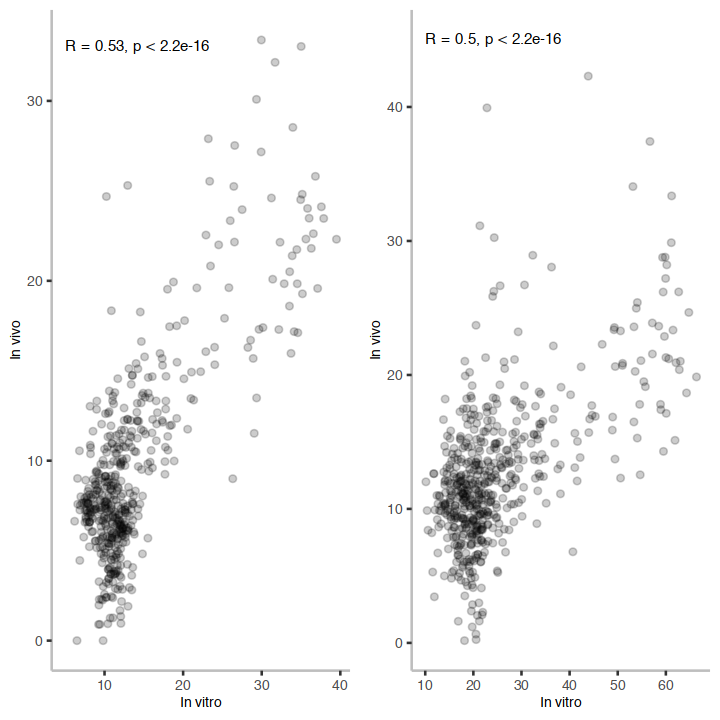

In [135]:
figure_5e_top <- mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p3*100,y=i79_p21*100))+
    geom_point(alpha=0.2)+
    stat_cor(method = "spearman",label.x=5,label.y=33,size=3)+
        labs(x = "In vitro", y = "In vivo"
         )+
    theme(
      plot.title = element_text(size=8),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(hjust = 0.5),
      axis.line = element_line(color = "grey"),
      theme(plot.margin = unit(c(0.5, 0.5, 0.5, 1.2), "cm"))
    )

figure_5e_bottom <- mean_editing_per_boxb_variants_wide %>%
    ggplot(aes(x=i79_p20*100,y=i79_p22*100))+
    geom_point(alpha=0.2)+
    stat_cor(method = "spearman",label.x=10,label.y=45,size=3)+
        labs(x = "In vitro", y = "In vivo"
         )+
    theme(
      plot.title = element_text(size=8),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(hjust = 0.5),
      axis.line = element_line(color = "grey"),
      theme(plot.margin = unit(c(0.5, 0.5, 0.5, 1.2), "cm"))
    )

plot_grid(figure_5e_top,figure_5e_bottom,nrow=1)

ggsave("../figures/in_vivo_vs_in_vitro.pdf",height = 2.0,width = 4)

### 5F

In [134]:
figure_5f_top <- editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",enzyme!="none")%>%
    ggplot(aes(x=gnra,y=fraction_edited*100,fill=gnra))+
        facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),strip.position = "top")+
        geom_point(color="grey50")+
        geom_violin(alpha=0.3)+
        geom_boxplot(width = 0.2, fill = "white", alpha=0.3, color = "black", outlier.shape = NA) +
        theme_classic()+
        scale_fill_manual(values=cbPalette,guide="none")+
        labs(x = "boxB Loop Sequence", y = "Mean Percent Edited"
         )+
        scale_x_discrete(labels=c("Not GNRNA","GNRNA"))+
        scale_y_continuous(limits=c(0,70))+
        theme(
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            axis.line = element_line(color = "grey"),
            strip.text = element_blank()
        )+
        stat_compare_means(
            method = "wilcox.test",      
            label = "p.format",           
            comparisons = list(c("TRUE", "FALSE")),
            label.y = 62,
            size=3)

ggsave("../figures/gnra.pdf",height = 1.75,width = 3) 

### 5G

In [137]:
figure_5g_top <- mean_editing_stem_variants %>%   
    filter(enzyme!="none")%>%
    ggplot(aes(x=as_factor(energy_bins),y=mean_fraction_edited*100,fill=as_factor(energy_bins)))+
    facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),strip.position = "top")+
    # geom_violin()+
    geom_boxplot(width = 0.6,  color = "black", outlier.shape = NA )+
    theme_classic()+
    scale_x_discrete(labels=c("0-20%","21-40%","41-60%","61-80%","81-100%"))+
    scale_y_continuous(limits=c(0,48))+
        stat_compare_means(
        method = "wilcox.test",      
        label = "p.signif",           
        comparisons = list(c("1","2"),c("2","3"),c("3","4"),c("4","5")),
        label.y = c(40, 35, 30, 25),
        size=3)+
    scale_fill_manual(values=cbPalette,guide=FALSE)+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
      strip.text=element_blank()
    )+
        labs(x = "Free Energy Percentile", y = "Percent Edited",fill="Timepoint"
         )

ggsave("../figures/stem_stability.pdf",height = 2.5,width = 3)  

## Supplementary Figure 4

### S4a and S4b

`summarise()` has grouped output by 'enzyme', 'boxb_8_rc'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'enzyme', 'boxb_12_rc'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'boxb_13_rc', 'boxb_7_rc'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'boxb_13_rc', 'boxb_7_rc'. You can override
using the `.groups` argument.


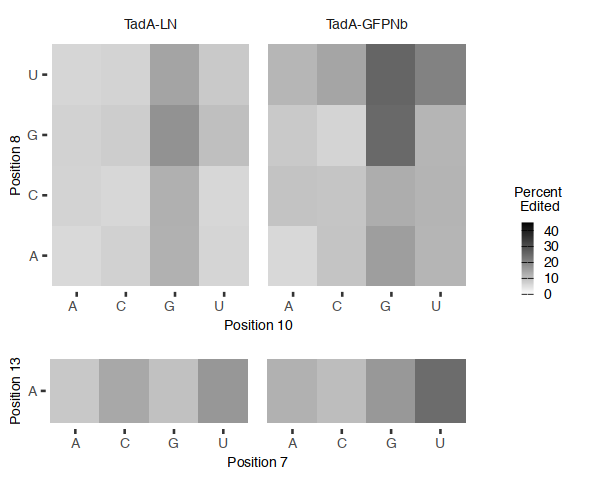

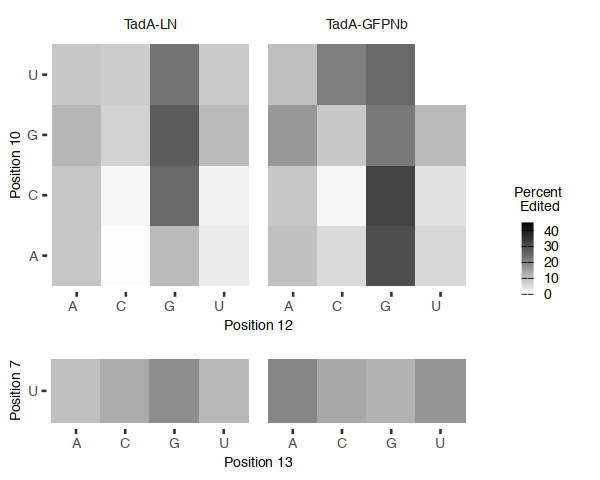

In [14]:
fig_S4a_top <-mean_editing_per_loop_variant %>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="7_10",enzyme!="none")%>% 
    group_by(enzyme,boxb_8_rc,boxb_10_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    #7-13 base pair is v important for binding and disruption overpowers gnra
    ggplot(aes(x=boxb_8_rc,y=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        scale_fill_gradient(
            name="Percent \nEdited",
            low = "white", high = "black",
            limits = c(0, 45),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        theme(axis.text.x = element_text(hjust = 1),
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8, hjust=0.5),
        legend.text = element_text(size = 8),
        strip.text.x = element_text(size = 8),
        legend.position="none"
        )+
        labs(y = "Position 8", x = "Position 10",
         )

ggsave("../figures/heatmaps_8_10.pdf",height = 1.75,width = 3.8)  

fig_S4b_top <- mean_editing_per_loop_variant%>%
    filter(boxb_7=="A"&boxb_13=="T",variable_subpos=="10_13",enzyme!="none")%>% 
    #7-13 base pair is v important for binding and disruption overpowers gnra
    group_by(enzyme,boxb_12_rc,boxb_10_rc)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    ggplot(aes(y=boxb_12_rc,x=boxb_10_rc,fill=mean_percent))+
        geom_tile()+
        facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(0, 45),
            guide = FALSE)+
        theme(axis.text.x = element_text(hjust = 1),
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        strip.text.x = element_text(size = 8)
        )+
        labs(x = "Position 12", y = "Position 10",
         )

ggsave("../figures/heatmaps_10_12.pdf",height = 1.75,width = 3.8) 

fig_S4a_bottom <- mean_editing_per_loop_variant %>%
    filter(boxb_8=="C"&boxb_9=="T"&boxb_10%in% c("T","C"),variable_subpos=="7_10",enzyme!="none")%>% 
    #7-13 base pair is v important for binding and disruption overpowers gnra
    group_by(boxb_13_rc,boxb_7_rc,enzyme)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    ggplot(aes(x=boxb_7_rc,y=boxb_13_rc,fill=mean_percent))+
        geom_tile()+
        facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(0, 45),
            guide = FALSE)+
        theme(
        axis.title.x = element_text(margin = margin(t = 4)),
        axis.line = element_blank(),
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        strip.text.x= element_blank()
        )+
        labs(x = "Position 7", y = "Position 13",
         )

ggsave("../figures/heatmaps_7_gfpnb.pdf",height = 1.0,width = 2.2)  

fig_S4b_bottom <-mean_editing_per_loop_variant %>%
    filter(boxb_10  %in% c("T","C"),boxb_12=="T",variable_subpos=="10_13",enzyme!="none")%>% 
    #7-13 base pair is v important for binding and disruption overpowers gnra
    group_by(boxb_13_rc,boxb_7_rc,enzyme)%>%
    summarize(mean_percent=mean(mean_fraction_edited)*100)%>%
    ggplot(aes(x=boxb_13_rc,y=boxb_7_rc,fill=mean_percent))+
        geom_tile()+
        facet_wrap(~factor(enzyme,levels=enzyme_order),labeller=as_labeller(facet_labels),nrow=1)+
        scale_fill_gradient(
            name="Percent Edited",
            low = "white", high = "black",
            limits = c(0, 45),
            guide = FALSE)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            strip.text.x= element_blank(),
            )+
        labs(x = "Position 13", y = "Position 7",
         )

ggsave("../figures/heatmaps_13_gfpnb.pdf",height = 1.0,width = 2.2)  

shared_legend <- get_legend(
  fig_S4a_top + theme(
    legend.position = "right",
    legend.justification = "center"
  )
)

# top_row <- plot_grid(
#   figure_4e_1,figure_4e_2,
#   ncol = 2
# )

# bottom_row <- plot_grid(
#   figure_4e_3,figure_4e_4,
#   ncol = 2
# )

# Stack them with different relative heights
plots_S4a <- plot_grid(
  fig_S4a_top,fig_S4a_bottom,
  ncol = 1,
  rel_heights = c(1, 0.4)
)

# Stack them with different relative heights
plots_S4b <- plot_grid(
  fig_S4b_top,fig_S4b_bottom,
  ncol = 1,
  rel_heights = c(1, 0.4)
)

# Add shared legend
figure_S4a <- plot_grid(
  plots_S4a, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(figure_S4a)

ggsave("../figures/figure_S4a.pdf",height = 2,width = 2.5) 

# Add shared legend
figure_S4b <- plot_grid(
  plots_S4b, shared_legend,
  rel_widths = c(1, 0.25)
)

# Show final plot
print(figure_S4b)


ggsave("../figures/figure_S4b.pdf",height = 2,width = 2.5) 